# 解析 Erdos Renyi Model

This notebook serve as an analysis for the Bornholdt Model Data. \
It is also a reference for the standard procedure to analyze all other models. \
The Bornholdt model output contain 3 time series, which is:
1. Magnetization (Price)
2. Fundamentalist (Number of Fundamentalist)
3. Average Local Disorder

We'd like to analyze the data by plotting:
1. The return distribution (r(t) = log|M(t)| - log|M(t-1)|) \
To understand the return type, we'd like to see the kurtosis of the distribution and compare it to a normal distribution.

2. How do we know if the returns is correlated ? \
We plot ACF for r(t)

3. How do we see volatility clustering ? \
We plot ACF for |r(t)|

4. How do we know the thickness of the tails ? \

5. How do we see the correlations between Volatility, Fundamentalists, and Disorder State?


In [10]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf
from matplotlib_inline.backend_inline import set_matplotlib_formats
from src.analysis.data import load_single_experiment_data

set_matplotlib_formats('svg')
plt.style.use('default')
pd.set_option('mode.copy_on_write', True)
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
df = load_single_experiment_data('../results/erdos_renyi/magnetization.csv', (40, 1.2))
df = df[300:]

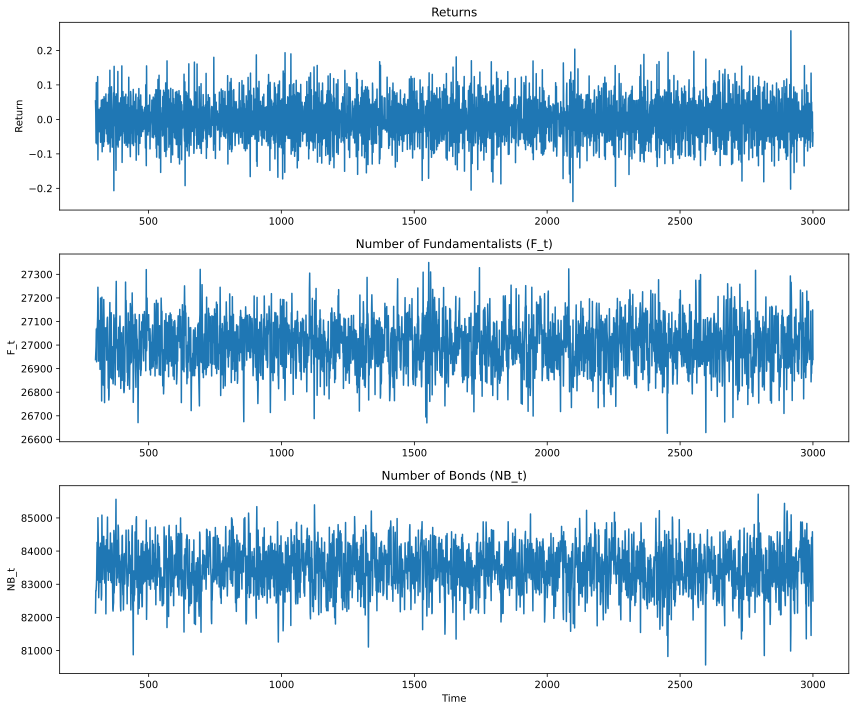

In [12]:
df['return'] = np.log(np.abs(df['M_t'])) - np.log(np.abs(df['M_t'].shift(1)))

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot returns
axes[0].plot(df['return'])
axes[0].set_title('Returns')
axes[0].set_ylabel('Return')

# Plot F_t
axes[1].plot(df['F_t'])
axes[1].set_title('Number of Fundamentalists (F_t)')
axes[1].set_ylabel('F_t')

# Plot NB_t
axes[2].plot(df['NB_t'])
axes[2].set_title('Number of Bonds (NB_t)')
axes[2].set_ylabel('NB_t')
axes[2].set_xlabel('Time')

plt.tight_layout()
plt.show()

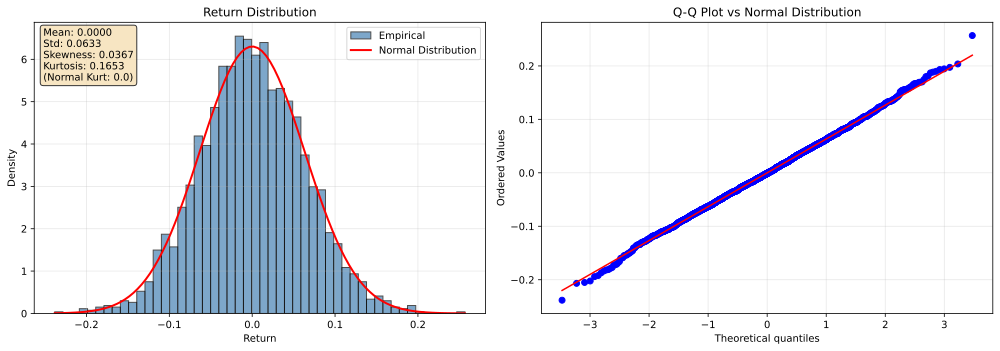


Return Distribution Statistics:
Mean: 0.000008
Std Dev: 0.063298
Skewness: 0.036689
Excess Kurtosis: 0.165293 (Normal = 0)

Note: Positive kurtosis indicates fat tails (leptokurtic)
      Negative kurtosis indicates thin tails (platykurtic)


In [13]:
# Return Distribution Analysis
returns = df['return'].dropna()
# Remove infinite values (from log(0))
returns = returns[np.isfinite(returns)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram with fitted normal distribution
ax1 = axes[0]
ax1.hist(returns, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black', label='Empirical')

# Fit normal distribution
mu, sigma = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 100)
normal_pdf = stats.norm.pdf(x, mu, sigma)
ax1.plot(x, normal_pdf, 'r-', linewidth=2, label='Normal Distribution')

# Calculate statistics
kurtosis = stats.kurtosis(returns)
skewness = stats.skew(returns)

ax1.set_xlabel('Return')
ax1.set_ylabel('Density')
ax1.set_title('Return Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add text box with statistics
textstr = f'Mean: {mu:.4f}\nStd: {sigma:.4f}\nSkewness: {skewness:.4f}\nKurtosis: {kurtosis:.4f}\n(Normal Kurt: 0.0)'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=props)

# Right: Q-Q plot
ax2 = axes[1]
stats.probplot(returns, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot vs Normal Distribution')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nReturn Distribution Statistics:")
print(f"Mean: {mu:.6f}")
print(f"Std Dev: {sigma:.6f}")
print(f"Skewness: {skewness:.6f}")
print(f"Excess Kurtosis: {kurtosis:.6f} (Normal = 0)")
print(f"\nNote: Positive kurtosis indicates fat tails (leptokurtic)")
print(f"      Negative kurtosis indicates thin tails (platykurtic)")


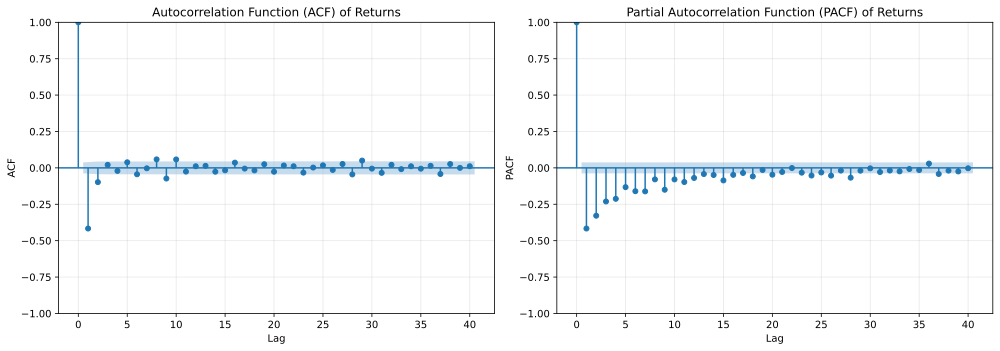


ACF Analysis:
Total lags tested: 40
Significant lags (at 95% confidence): 7

Significant autocorrelations found at lags:
  Lag 1: -0.4166
  Lag 2: -0.0979
  Lag 8: 0.0585
  Lag 9: -0.0732
  Lag 10: 0.0581
  Lag 28: -0.0449
  Lag 29: 0.0502

Ljung-Box Test (tests for overall correlation):
       lb_stat      lb_pvalue
10  539.654675  1.465787e-109
20  552.965804  2.262407e-104
30  572.765699  1.270704e-101

Interpretation: p-value < 0.05 suggests significant autocorrelation


In [14]:
# ACF Analysis for Returns - Check if returns are correlated
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF plot
ax1 = axes[0]
plot_acf(returns, lags=40, ax=ax1, alpha=0.05)
ax1.set_title('Autocorrelation Function (ACF) of Returns')
ax1.set_xlabel('Lag')
ax1.set_ylabel('ACF')
ax1.grid(True, alpha=0.3)

# PACF plot
ax2 = axes[1]
plot_pacf(returns, lags=40, ax=ax2, alpha=0.05)
ax2.set_title('Partial Autocorrelation Function (PACF) of Returns')
ax2.set_xlabel('Lag')
ax2.set_ylabel('PACF')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate ACF values and check for significant correlations
acf_values = acf(returns, nlags=40, alpha=0.05)
significant_lags = []
for i in range(1, len(acf_values[0])):
    if abs(acf_values[0][i]) > (acf_values[1][i][1] - acf_values[0][i]):
        significant_lags.append((i, acf_values[0][i]))

print(f"\nACF Analysis:")
print(f"Total lags tested: 40")
print(f"Significant lags (at 95% confidence): {len(significant_lags)}")
if significant_lags:
    print(f"\nSignificant autocorrelations found at lags:")
    for lag, value in significant_lags[:10]:  # Show first 10
        print(f"  Lag {lag}: {value:.4f}")
else:
    print("\nNo significant autocorrelations found.")
    print("Returns appear to be uncorrelated (similar to random walk).")

# Ljung-Box test for overall correlation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(returns, lags=[10, 20, 30], return_df=True)
print(f"\nLjung-Box Test (tests for overall correlation):")
print(lb_test)
print(f"\nInterpretation: p-value < 0.05 suggests significant autocorrelation")


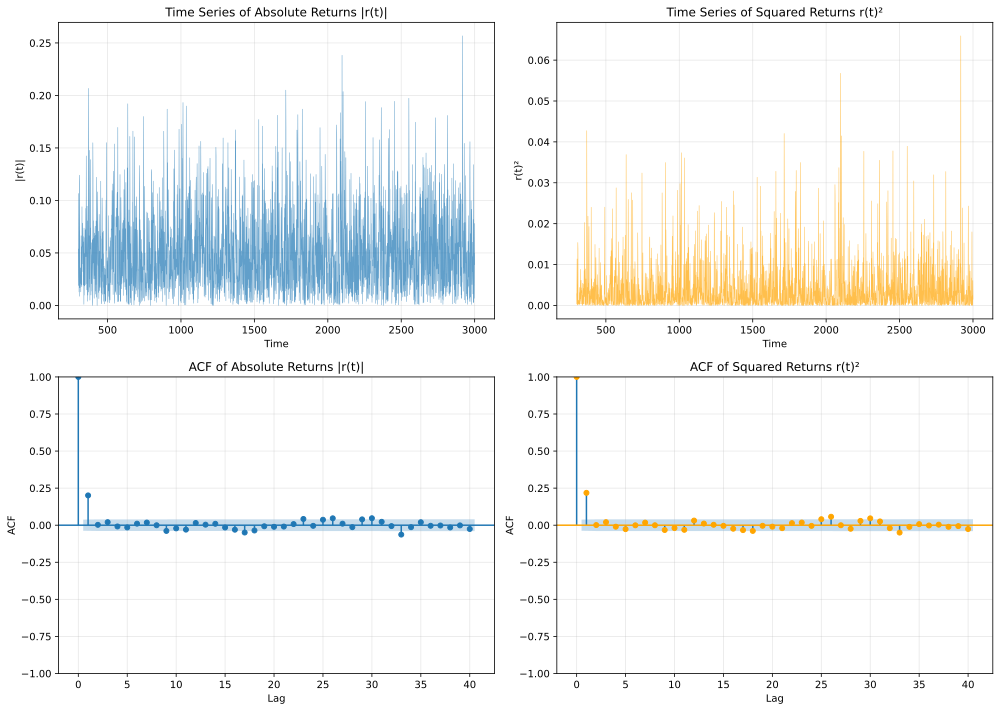


VOLATILITY CLUSTERING ANALYSIS

Absolute Returns |r(t)|:
  Significant lags: 6/40
  First 10 significant lags:
    Lag 1: 0.2009
    Lag 17: -0.0494
    Lag 23: 0.0419
    Lag 26: 0.0464
    Lag 30: 0.0469
    Lag 33: -0.0634

Squared Returns r(t)²:
  Significant lags: 5/40
  First 10 significant lags:
    Lag 1: 0.2182
    Lag 25: 0.0403
    Lag 26: 0.0570
    Lag 30: 0.0461
    Lag 33: -0.0499

Ljung-Box Test for |r(t)|:
       lb_stat     lb_pvalue
10  117.468440  1.649986e-20
20  134.527976  5.485005e-19
30  160.323364  9.624370e-20

Ljung-Box Test for r(t)²:
       lb_stat     lb_pvalue
10  136.675004  2.021221e-24
20  151.253126  3.616454e-22
30  176.780643  9.900407e-23

INTERPRETATION:
Volatility clustering is present if:
  1. |r(t)| or r(t)² shows significant autocorrelation
  2. Ljung-Box p-values < 0.05

This indicates that large returns tend to follow large returns,
and small returns tend to follow small returns - a key stylized
fact of financial markets.


In [15]:
# Volatility Clustering Analysis - ACF for |r(t)|
abs_returns = np.abs(returns)
squared_returns = returns ** 2

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: Time series of absolute returns
ax1 = axes[0, 0]
ax1.plot(abs_returns.index, abs_returns.values, linewidth=0.5, alpha=0.7)
ax1.set_title('Time Series of Absolute Returns |r(t)|')
ax1.set_xlabel('Time')
ax1.set_ylabel('|r(t)|')
ax1.grid(True, alpha=0.3)

# Top right: Time series of squared returns
ax2 = axes[0, 1]
ax2.plot(squared_returns.index, squared_returns.values, linewidth=0.5, alpha=0.7, color='orange')
ax2.set_title('Time Series of Squared Returns r(t)²')
ax2.set_xlabel('Time')
ax2.set_ylabel('r(t)²')
ax2.grid(True, alpha=0.3)

# Bottom left: ACF of absolute returns
ax3 = axes[1, 0]
plot_acf(abs_returns, lags=40, ax=ax3, alpha=0.05)
ax3.set_title('ACF of Absolute Returns |r(t)|')
ax3.set_xlabel('Lag')
ax3.set_ylabel('ACF')
ax3.grid(True, alpha=0.3)

# Bottom right: ACF of squared returns
ax4 = axes[1, 1]
plot_acf(squared_returns, lags=40, ax=ax4, alpha=0.05, color='orange')
ax4.set_title('ACF of Squared Returns r(t)²')
ax4.set_xlabel('Lag')
ax4.set_ylabel('ACF')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical analysis for absolute returns
acf_abs = acf(abs_returns, nlags=40, alpha=0.05)
significant_lags_abs = []
for i in range(1, len(acf_abs[0])):
    if abs(acf_abs[0][i]) > (acf_abs[1][i][1] - acf_abs[0][i]):
        significant_lags_abs.append((i, acf_abs[0][i]))

# Statistical analysis for squared returns
acf_sq = acf(squared_returns, nlags=40, alpha=0.05)
significant_lags_sq = []
for i in range(1, len(acf_sq[0])):
    if abs(acf_sq[0][i]) > (acf_sq[1][i][1] - acf_sq[0][i]):
        significant_lags_sq.append((i, acf_sq[0][i]))

print(f"\n{'='*60}")
print(f"VOLATILITY CLUSTERING ANALYSIS")
print(f"{'='*60}")

print(f"\nAbsolute Returns |r(t)|:")
print(f"  Significant lags: {len(significant_lags_abs)}/40")
if significant_lags_abs:
    print(f"  First 10 significant lags:")
    for lag, value in significant_lags_abs[:10]:
        print(f"    Lag {lag}: {value:.4f}")

print(f"\nSquared Returns r(t)²:")
print(f"  Significant lags: {len(significant_lags_sq)}/40")
if significant_lags_sq:
    print(f"  First 10 significant lags:")
    for lag, value in significant_lags_sq[:10]:
        print(f"    Lag {lag}: {value:.4f}")

# Ljung-Box test for volatility clustering
lb_abs = acorr_ljungbox(abs_returns, lags=[10, 20, 30], return_df=True)
lb_sq = acorr_ljungbox(squared_returns, lags=[10, 20, 30], return_df=True)

print(f"\nLjung-Box Test for |r(t)|:")
print(lb_abs)

print(f"\nLjung-Box Test for r(t)²:")
print(lb_sq)

print(f"\n{'='*60}")
print(f"INTERPRETATION:")
print(f"{'='*60}")
print(f"Volatility clustering is present if:")
print(f"  1. |r(t)| or r(t)² shows significant autocorrelation")
print(f"  2. Ljung-Box p-values < 0.05")
print(f"\nThis indicates that large returns tend to follow large returns,")
print(f"and small returns tend to follow small returns - a key stylized")
print(f"fact of financial markets.")


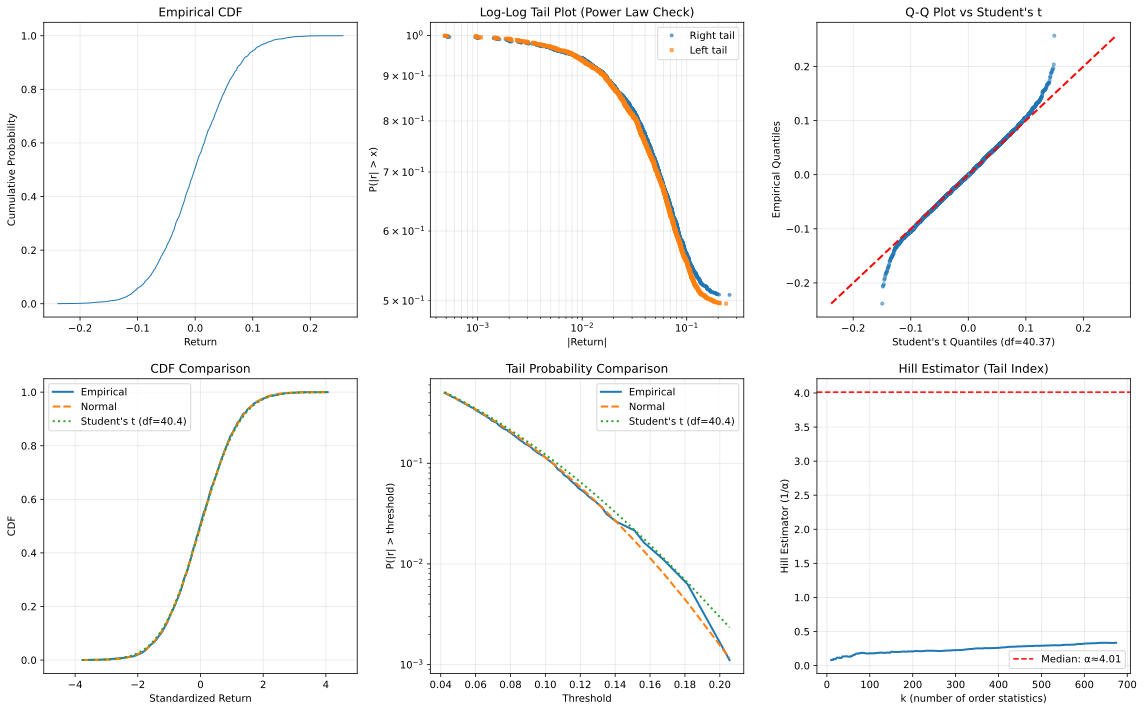


TAIL THICKNESS ANALYSIS

Extreme Values:
  Maximum return: 0.2568
  Minimum return: -0.2383
  99th percentile: 0.1551
  1st percentile: -0.1480

Distribution Shape:
  Excess Kurtosis: 0.1653
  (Normal = 0, Higher = Fatter tails)

Best-fit Student's t Distribution:
  Degrees of freedom: 40.37
  (Lower df = Fatter tails, Normal ≈ df → ∞)

Hill Estimator (Tail Index α):
  Estimated α: 4.01
  (α < 2: Infinite variance, α < 4: Finite variance but heavy tails)
  (Normal: α → ∞)

Extreme Events (beyond 3σ):
  Observed: 12 (0.44%)
  Expected (Normal): 7.3 (0.27%)
  Ratio: 1.65x

INTERPRETATION:
Fat tails are indicated by:
  1. High excess kurtosis (> 3)
  2. Linear pattern in log-log tail plot
  3. Student's t with low df fits better than Normal
  4. More extreme events than Normal predicts
  5. Hill estimator α < 4


In [16]:
# Tail Thickness Analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Empirical CDF with zoom on tails
ax1 = axes[0, 0]
sorted_returns = np.sort(returns)
ecdf = np.arange(1, len(sorted_returns) + 1) / len(sorted_returns)
ax1.plot(sorted_returns, ecdf, linewidth=1)
ax1.set_xlabel('Return')
ax1.set_ylabel('Cumulative Probability')
ax1.set_title('Empirical CDF')
ax1.grid(True, alpha=0.3)

# 2. Log-log plot of tail probabilities (Complementary CDF)
ax2 = axes[0, 1]
# Right tail (positive returns)
pos_returns = sorted_returns[sorted_returns > 0]
pos_ccdf = 1 - np.arange(1, len(pos_returns) + 1) / len(sorted_returns)
# Remove zeros for log scale
pos_ccdf_nonzero = pos_ccdf[pos_ccdf > 0]
pos_returns_nonzero = pos_returns[:len(pos_ccdf_nonzero)]
if len(pos_returns_nonzero) > 0:
    ax2.loglog(pos_returns_nonzero, pos_ccdf_nonzero, 'o', markersize=3, alpha=0.6, label='Right tail')

# Left tail (negative returns)
neg_returns = -sorted_returns[sorted_returns < 0][::-1]
neg_ccdf = 1 - np.arange(1, len(neg_returns) + 1) / len(sorted_returns)
neg_ccdf_nonzero = neg_ccdf[neg_ccdf > 0]
neg_returns_nonzero = neg_returns[:len(neg_ccdf_nonzero)]
if len(neg_returns_nonzero) > 0:
    ax2.loglog(neg_returns_nonzero, neg_ccdf_nonzero, 's', markersize=3, alpha=0.6, label='Left tail')

ax2.set_xlabel('|Return|')
ax2.set_ylabel('P(|r| > x)')
ax2.set_title('Log-Log Tail Plot (Power Law Check)')
ax2.legend()
ax2.grid(True, alpha=0.3, which='both')

# 3. Quantile-Quantile plot vs different distributions
ax3 = axes[0, 2]
# Compare with Student's t distribution
from scipy.stats import t as student_t
# Fit t-distribution
params = student_t.fit(returns)
df_fitted = params[0]
theoretical_quantiles = student_t.ppf(np.linspace(0.01, 0.99, len(returns)), df_fitted, params[1], params[2])
ax3.scatter(np.sort(theoretical_quantiles), sorted_returns, alpha=0.5, s=10)
ax3.plot([sorted_returns.min(), sorted_returns.max()], 
         [sorted_returns.min(), sorted_returns.max()], 'r--', linewidth=2)
ax3.set_xlabel(f'Student\'s t Quantiles (df={df_fitted:.2f})')
ax3.set_ylabel('Empirical Quantiles')
ax3.set_title('Q-Q Plot vs Student\'s t')
ax3.grid(True, alpha=0.3)

# 4. Tail comparison: Empirical vs Normal vs Student's t
ax4 = axes[1, 0]
# Standardize returns
standardized_returns = (returns - returns.mean()) / returns.std()
sorted_std = np.sort(standardized_returns)
empirical_probs = np.arange(1, len(sorted_std) + 1) / len(sorted_std)

# Normal CDF
normal_cdf = stats.norm.cdf(sorted_std)
# Student's t CDF
t_cdf = student_t.cdf(sorted_std, df_fitted)

ax4.plot(sorted_std, empirical_probs, label='Empirical', linewidth=2)
ax4.plot(sorted_std, normal_cdf, label='Normal', linewidth=2, linestyle='--')
ax4.plot(sorted_std, t_cdf, label=f'Student\'s t (df={df_fitted:.1f})', linewidth=2, linestyle=':')
ax4.set_xlabel('Standardized Return')
ax4.set_ylabel('CDF')
ax4.set_title('CDF Comparison')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim([-5, 5])

# 5. Tail probability comparison (focus on extremes)
ax5 = axes[1, 1]
# Focus on tails: P(|r| > threshold)
thresholds = np.percentile(np.abs(returns), np.linspace(50, 99.9, 100))
empirical_tail_probs = [np.mean(np.abs(returns) > t) for t in thresholds]

# Compare with Normal
std_returns = returns.std()
normal_tail_probs = [2 * (1 - stats.norm.cdf(t / std_returns)) for t in thresholds]

# Compare with fitted Student's t
t_tail_probs = [2 * (1 - student_t.cdf(t / std_returns, df_fitted)) for t in thresholds]

ax5.semilogy(thresholds, empirical_tail_probs, label='Empirical', linewidth=2)
ax5.semilogy(thresholds, normal_tail_probs, label='Normal', linewidth=2, linestyle='--')
ax5.semilogy(thresholds, t_tail_probs, label=f'Student\'s t (df={df_fitted:.1f})', linewidth=2, linestyle=':')
ax5.set_xlabel('Threshold')
ax5.set_ylabel('P(|r| > threshold)')
ax5.set_title('Tail Probability Comparison')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Hill estimator for tail index
ax6 = axes[1, 2]
def hill_estimator(data, k_max=None):
    """Compute Hill estimator for various k"""
    abs_data = np.abs(data)
    sorted_data = np.sort(abs_data)[::-1]  # Sort descending
    
    if k_max is None:
        k_max = min(len(sorted_data) // 4, 1000)
    
    k_values = np.arange(10, k_max)
    hill_estimates = []
    
    for k in k_values:
        if k >= len(sorted_data):
            break
        log_ratios = np.log(sorted_data[:k] / sorted_data[k])
        hill_estimates.append(np.mean(log_ratios))
    
    return k_values[:len(hill_estimates)], np.array(hill_estimates)

k_values, hill_estimates = hill_estimator(returns)
ax6.plot(k_values, hill_estimates, linewidth=2)
ax6.axhline(y=1/hill_estimates[len(hill_estimates)//2], color='r', linestyle='--', 
            label=f'Median: α≈{1/hill_estimates[len(hill_estimates)//2]:.2f}')
ax6.set_xlabel('k (number of order statistics)')
ax6.set_ylabel('Hill Estimator (1/α)')
ax6.set_title('Hill Estimator (Tail Index)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical summary
print(f"\n{'='*60}")
print(f"TAIL THICKNESS ANALYSIS")
print(f"{'='*60}")

# Extreme values
print(f"\nExtreme Values:")
print(f"  Maximum return: {returns.max():.4f}")
print(f"  Minimum return: {returns.min():.4f}")
print(f"  99th percentile: {np.percentile(returns, 99):.4f}")
print(f"  1st percentile: {np.percentile(returns, 1):.4f}")

# Kurtosis (already computed, but reiterate)
print(f"\nDistribution Shape:")
print(f"  Excess Kurtosis: {stats.kurtosis(returns):.4f}")
print(f"  (Normal = 0, Higher = Fatter tails)")

# Fitted Student's t degrees of freedom
print(f"\nBest-fit Student's t Distribution:")
print(f"  Degrees of freedom: {df_fitted:.2f}")
print(f"  (Lower df = Fatter tails, Normal ≈ df → ∞)")

# Hill estimator
median_hill = 1 / hill_estimates[len(hill_estimates)//2]
print(f"\nHill Estimator (Tail Index α):")
print(f"  Estimated α: {median_hill:.2f}")
print(f"  (α < 2: Infinite variance, α < 4: Finite variance but heavy tails)")
print(f"  (Normal: α → ∞)")

# Test for extreme values beyond 3 sigma
n_beyond_3sigma = np.sum(np.abs(returns - returns.mean()) > 3 * returns.std())
expected_beyond_3sigma = len(returns) * 0.0027  # For normal distribution

print(f"\nExtreme Events (beyond 3σ):")
print(f"  Observed: {n_beyond_3sigma} ({100*n_beyond_3sigma/len(returns):.2f}%)")
print(f"  Expected (Normal): {expected_beyond_3sigma:.1f} ({0.27:.2f}%)")
print(f"  Ratio: {n_beyond_3sigma/expected_beyond_3sigma:.2f}x")

print(f"\n{'='*60}")
print(f"INTERPRETATION:")
print(f"{'='*60}")
print(f"Fat tails are indicated by:")
print(f"  1. High excess kurtosis (> 3)")
print(f"  2. Linear pattern in log-log tail plot")
print(f"  3. Student's t with low df fits better than Normal")
print(f"  4. More extreme events than Normal predicts")
print(f"  5. Hill estimator α < 4")

/var/folders/q_/2nhldr_d2x723c91y7qt5g2r0000gn/T/ipykernel_33403/1419270895.py:135: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


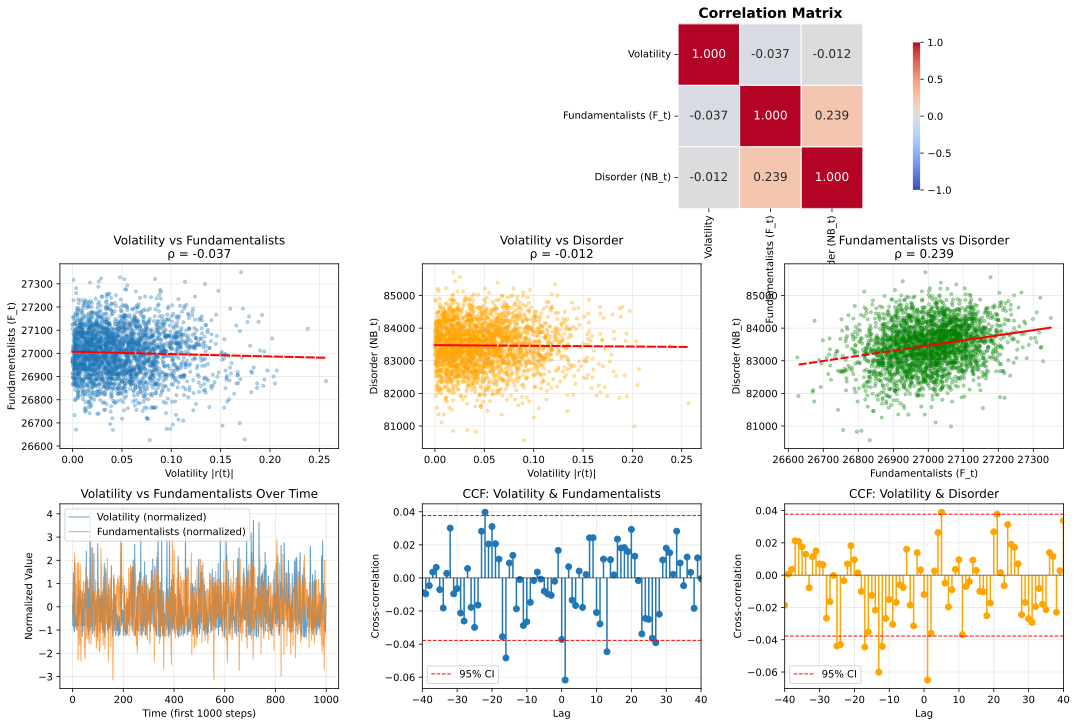


CORRELATION ANALYSIS: Volatility, Fundamentalists, Disorder

Pearson Correlation Coefficients:
                       Volatility  Fundamentalists (F_t)  Disorder (NB_t)
Volatility               1.000000              -0.037173        -0.012023
Fundamentalists (F_t)   -0.037173               1.000000         0.238566
Disorder (NB_t)         -0.012023               0.238566         1.000000


Spearman Correlation (rank-based, for non-linear relationships):
                       Volatility  Fundamentalists (F_t)  Disorder (NB_t)
Volatility               1.000000              -0.018975         0.006642
Fundamentalists (F_t)   -0.018975               1.000000         0.228434
Disorder (NB_t)          0.006642               0.228434         1.000000


Statistical Significance Tests:
------------------------------------------------------------
Volatility vs Fundamentalists:
  Pearson r: -0.0372, p-value: 5.34e-02
  Not significant at α=0.05

Volatility vs Disorder:
  Pearson r: -0.0120, p-va

In [17]:
# Correlations between Volatility, Fundamentalists, and Disorder State
# Prepare data
df_clean = df.dropna()
df_clean['volatility'] = np.abs(df_clean['return'])
df_clean = df_clean[np.isfinite(df_clean['volatility'])]

# Create correlation dataframe
corr_data = pd.DataFrame({
    'Volatility': df_clean['volatility'].values,
    'Fundamentalists (F_t)': df_clean['F_t'].values,
    'Disorder (NB_t)': df_clean['NB_t'].values
})

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Correlation matrix heatmap
ax1 = fig.add_subplot(gs[0, :])
corr_matrix = corr_data.corr()
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax1,
            vmin=-1, vmax=1, fmt='.3f', annot_kws={'size': 12})
ax1.set_title('Correlation Matrix', fontsize=14, fontweight='bold')

# 2-4. Scatter plots with regression lines
ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(corr_data['Volatility'], corr_data['Fundamentalists (F_t)'], 
            alpha=0.3, s=10)
z = np.polyfit(corr_data['Volatility'], corr_data['Fundamentalists (F_t)'], 1)
p = np.poly1d(z)
ax2.plot(corr_data['Volatility'], p(corr_data['Volatility']), "r--", linewidth=2)
ax2.set_xlabel('Volatility |r(t)|')
ax2.set_ylabel('Fundamentalists (F_t)')
ax2.set_title(f'Volatility vs Fundamentalists\nρ = {corr_matrix.loc["Volatility", "Fundamentalists (F_t)"]:.3f}')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ax3.scatter(corr_data['Volatility'], corr_data['Disorder (NB_t)'], 
            alpha=0.3, s=10, color='orange')
z = np.polyfit(corr_data['Volatility'], corr_data['Disorder (NB_t)'], 1)
p = np.poly1d(z)
ax3.plot(corr_data['Volatility'], p(corr_data['Volatility']), "r--", linewidth=2)
ax3.set_xlabel('Volatility |r(t)|')
ax3.set_ylabel('Disorder (NB_t)')
ax3.set_title(f'Volatility vs Disorder\nρ = {corr_matrix.loc["Volatility", "Disorder (NB_t)"]:.3f}')
ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[1, 2])
ax4.scatter(corr_data['Fundamentalists (F_t)'], corr_data['Disorder (NB_t)'], 
            alpha=0.3, s=10, color='green')
z = np.polyfit(corr_data['Fundamentalists (F_t)'], corr_data['Disorder (NB_t)'], 1)
p = np.poly1d(z)
ax4.plot(corr_data['Fundamentalists (F_t)'], p(corr_data['Fundamentalists (F_t)']), "r--", linewidth=2)
ax4.set_xlabel('Fundamentalists (F_t)')
ax4.set_ylabel('Disorder (NB_t)')
ax4.set_title(f'Fundamentalists vs Disorder\nρ = {corr_matrix.loc["Fundamentalists (F_t)", "Disorder (NB_t)"]:.3f}')
ax4.grid(True, alpha=0.3)

# 5. Time series overlay (normalized)
ax5 = fig.add_subplot(gs[2, 0])
# Normalize for comparison
vol_norm = (corr_data['Volatility'] - corr_data['Volatility'].mean()) / corr_data['Volatility'].std()
ft_norm = (corr_data['Fundamentalists (F_t)'] - corr_data['Fundamentalists (F_t)'].mean()) / corr_data['Fundamentalists (F_t)'].std()

ax5.plot(vol_norm.values[:1000], label='Volatility (normalized)', alpha=0.7, linewidth=1)
ax5.plot(ft_norm.values[:1000], label='Fundamentalists (normalized)', alpha=0.7, linewidth=1)
ax5.set_xlabel('Time (first 1000 steps)')
ax5.set_ylabel('Normalized Value')
ax5.set_title('Volatility vs Fundamentalists Over Time')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Cross-correlation function
ax6 = fig.add_subplot(gs[2, 1])

# Manual CCF calculation
def compute_ccf(x, y, max_lag=40):
    """Compute cross-correlation function manually"""
    # Standardize the series
    x = (x - np.mean(x)) / np.std(x)
    y = (y - np.mean(y)) / np.std(y)
    
    lags = np.arange(-max_lag, max_lag + 1)
    ccf_values = []
    
    for lag in lags:
        if lag < 0:
            # Negative lag: x leads y
            ccf_val = np.corrcoef(x[:lag], y[-lag:])[0, 1]
        elif lag > 0:
            # Positive lag: y leads x
            ccf_val = np.corrcoef(x[lag:], y[:-lag])[0, 1]
        else:
            # Zero lag
            ccf_val = np.corrcoef(x, y)[0, 1]
        ccf_values.append(ccf_val)
    
    return lags, np.array(ccf_values)

# CCF between Volatility and Fundamentalists
lags, ccf_vol_ft = compute_ccf(corr_data['Volatility'].values, 
                                corr_data['Fundamentalists (F_t)'].values, 
                                max_lag=40)

ax6.stem(lags, ccf_vol_ft, basefmt=' ')
ax6.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ci = 1.96/np.sqrt(len(corr_data))
ax6.axhline(y=ci, color='r', linestyle='--', linewidth=1, label='95% CI')
ax6.axhline(y=-ci, color='r', linestyle='--', linewidth=1)
ax6.set_xlabel('Lag')
ax6.set_ylabel('Cross-correlation')
ax6.set_title('CCF: Volatility & Fundamentalists')
ax6.legend()
ax6.grid(True, alpha=0.3)
ax6.set_xlim([-40, 40])

# 7. Cross-correlation: Volatility and Disorder
ax7 = fig.add_subplot(gs[2, 2])
lags, ccf_vol_nb = compute_ccf(corr_data['Volatility'].values, 
                                corr_data['Disorder (NB_t)'].values, 
                                max_lag=40)

ax7.stem(lags, ccf_vol_nb, basefmt=' ', linefmt='orange', markerfmt='o')
ax7.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax7.axhline(y=ci, color='r', linestyle='--', linewidth=1, label='95% CI')
ax7.axhline(y=-ci, color='r', linestyle='--', linewidth=1)
ax7.set_xlabel('Lag')
ax7.set_ylabel('Cross-correlation')
ax7.set_title('CCF: Volatility & Disorder')
ax7.legend()
ax7.grid(True, alpha=0.3)
ax7.set_xlim([-40, 40])

plt.tight_layout()
plt.show()

# Statistical summary
print(f"\n{'='*60}")
print(f"CORRELATION ANALYSIS: Volatility, Fundamentalists, Disorder")
print(f"{'='*60}")

print(f"\nPearson Correlation Coefficients:")
print(corr_matrix.to_string())

print(f"\n\nSpearman Correlation (rank-based, for non-linear relationships):")
spearman_corr = corr_data.corr(method='spearman')
print(spearman_corr.to_string())

# Statistical significance tests
from scipy.stats import pearsonr, spearmanr

print(f"\n\nStatistical Significance Tests:")
print("-" * 60)

# Vol vs F_t
r_val, p_val = pearsonr(corr_data['Volatility'], corr_data['Fundamentalists (F_t)'])
print(f"Volatility vs Fundamentalists:")
print(f"  Pearson r: {r_val:.4f}, p-value: {p_val:.2e}")
print(f"  {'Significant' if p_val < 0.05 else 'Not significant'} at α=0.05")

# Vol vs NB_t
r_val, p_val = pearsonr(corr_data['Volatility'], corr_data['Disorder (NB_t)'])
print(f"\nVolatility vs Disorder:")
print(f"  Pearson r: {r_val:.4f}, p-value: {p_val:.2e}")
print(f"  {'Significant' if p_val < 0.05 else 'Not significant'} at α=0.05")

# F_t vs NB_t
r_val, p_val = pearsonr(corr_data['Fundamentalists (F_t)'], corr_data['Disorder (NB_t)'])
print(f"\nFundamentalists vs Disorder:")
print(f"  Pearson r: {r_val:.4f}, p-value: {p_val:.2e}")
print(f"  {'Significant' if p_val < 0.05 else 'Not significant'} at α=0.05")

print(f"\n{'='*60}")
print(f"INTERPRETATION:")
print(f"{'='*60}")
print(f"Positive correlation → Variables move together")
print(f"Negative correlation → Variables move in opposite directions")
print(f"Near zero → No linear relationship")
print(f"\nCross-correlation function (CCF) shows lagged relationships:")
print(f"  - Positive lag: Y follows X")
print(f"  - Negative lag: X follows Y")
print(f"  - Peak at lag k: strongest relationship at k time steps")
